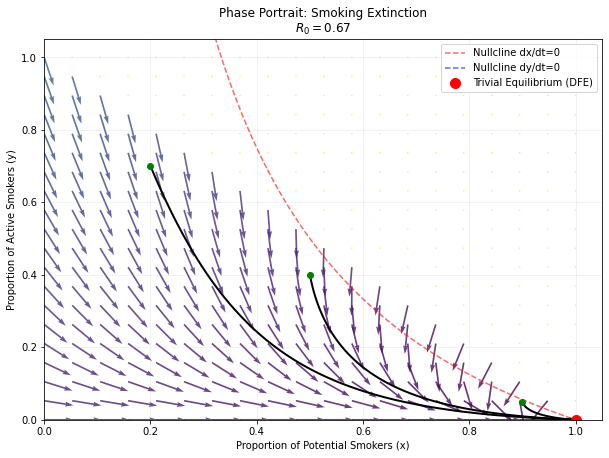

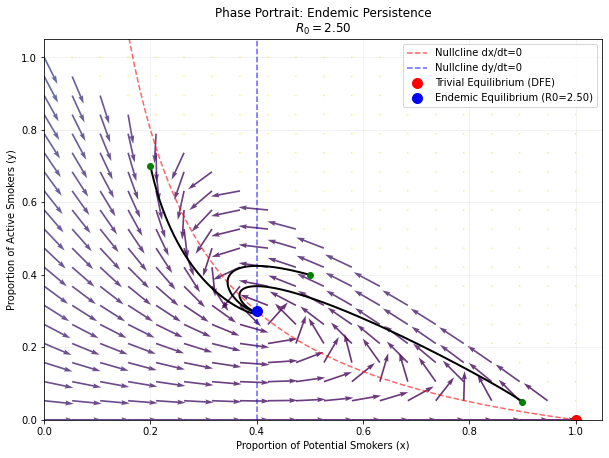

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def plot_phase_portrait(beta, mu, gamma, title):
    # Calculate Basic Reproduction Number (R0)
    R0 = beta / (mu + gamma)
    
    # Reduced system for normalized variables: x = P/N, y = S/N
    # (z = Q/N is omitted since x + y + z = 1)
    def reduced_system(state, t):
        x, y = state
        dxdt = mu - beta * x * y - mu * x
        dydt = beta * x * y - (mu + gamma) * y
        return [dxdt, dydt]

    # Create a grid for the vector field
    x_range = np.linspace(0, 1.0, 20)
    y_range = np.linspace(0, 1.0, 20)
    X, Y = np.meshgrid(x_range, y_range)
    
    U, V = np.zeros(X.shape), np.zeros(Y.shape)
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            # Biological constraint: x + y <= 1
            if X[i,j] + Y[i,j] <= 1.05:
                dx, dy = reduced_system([X[i,j], Y[i,j]], 0)
                U[i,j], V[i,j] = dx, dy

    plt.figure(figsize=(10, 7))
    
    # Plot Vector Field (Normalized for clarity)
    strength = np.sqrt(U**2 + V**2)
    strength[strength == 0] = 1 # Avoid division by zero
    plt.quiver(X, Y, U/strength, V/strength, strength, cmap='viridis', alpha=0.8)

    # Plot Nullclines
    # dx/dt = 0 => y = (mu * (1-x)) / (beta * x)
    x_null = np.linspace(0.01, 1, 100)
    plt.plot(x_null, (mu*(1-x_null))/(beta*x_null), 'r--', label='Nullcline dx/dt=0', alpha=0.6)
    # dy/dt = 0 => x = (mu + gamma) / beta = 1/R0
    plt.axvline(x=(mu+gamma)/beta, color='blue', linestyle='--', label='Nullcline dy/dt=0', alpha=0.6)

    # Simulate Trajectories from different initial conditions
    t = np.linspace(0, 100, 1000)
    initial_states = [[0.9, 0.05], [0.5, 0.4], [0.2, 0.7]]
    for start in initial_states:
        sol = odeint(reduced_system, start, t)
        plt.plot(sol[:,0], sol[:,1], 'k-', lw=2)
        plt.plot(start[0], start[1], 'go') # Starting point

    # Mark Equilibria
    plt.plot(1, 0, 'ro', markersize=10, label='Trivial Equilibrium (DFE)')
    if R0 > 1:
        x_star = (mu + gamma) / beta
        y_star = (mu * (1 - x_star)) / (mu + gamma)
        plt.plot(x_star, y_star, 'bo', markersize=10, label=f'Endemic Equilibrium (R0={R0:.2f})')

    plt.title(f"{title}\n$R_0 = {R0:.2f}$")
    plt.xlabel("Proportion of Potential Smokers (x)")
    plt.ylabel("Proportion of Active Smokers (y)")
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# --- Scenarios ---

# Case 1: R0 < 1 (Smoking dies out)
plot_phase_portrait(beta=0.2, mu=0.1, gamma=0.2, title="Phase Portrait: Smoking Extinction")

# Case 2: R0 > 1 (Smoking persists)
plot_phase_portrait(beta=0.5, mu=0.1, gamma=0.1, title="Phase Portrait: Endemic Persistence")

### Interpretation of Simulation Results

The phase portrait generated by the script provides a visual representation of the system's long-term dynamics. The behavior is governed by the following key elements:

#### The Basic Reproduction Number ($R_0$)
The most critical value in the results is the threshold quantity:
$ R_0 = \frac{\beta}{\mu + \gamma}$
It acts as a biological and social threshold:
    $\textbf{If $R_0 < 1$:}$ Each smoker recruits, on average, fewer than one new smoker before leaving the system. Smoking will eventually vanish.
    $ \textbf{If $R_0 > 1$:}$ Each smoker recruits more than one person. Smoking will persist as a "social endemic."

 #### Case 1: Smoking Extinction ($R_0 < 1$)
In this scenario, the plot demonstrates the following:
    $\textbf{Vector Field (Arrows):}$ All arrows across the graph converge toward the point $(1, 0)$.
    $\textbf{Trivial Equilibrium (DFE):}$ The red dot at $(x=1, y=0)$ is a $\textbf{Global Attractor}$. This represents a "smoke-free" school where $100\%$ of the population consists of potential smokers and $0\%$ are active smokers.
    $\textbf{Stability:}$ Regardless of the initial number of smokers (green dots), the black trajectory lines curve down to zero. The system is $\textbf{Stable}$ at the trivial equilibrium.

#### Case 2: Endemic Persistence ($R_0 > 1$)
In this plot, the dynamics change drastically:
    $ \textbf{Trivial Equilibrium:}$ The point $(1, 0)$ becomes $\textbf{Unstable}$ (a "Saddle Point"). Arrows near it point away, showing that a single smoker can trigger an "outbreak."
    $\textbf{Endemic Equilibrium:}$ A blue dot appears inside the graph. This is the new $\textbf{Stable Equilibrium}$.
    $\textbf{Nullclines (Dashed Lines):}$ 
        $The \textbf{Blue Line}$ ($x = 1/R_0$) represents the critical threshold of potential smokers needed to maintain the smoking population.
        The intersection of the red and blue dashed lines marks exactly where the population stabilizes.
    $\textbf{Stability:}$ Trajectories spiral or move directly toward the blue dot. Without external intervention, a fixed percentage of students will remain active smokers indefinitely.


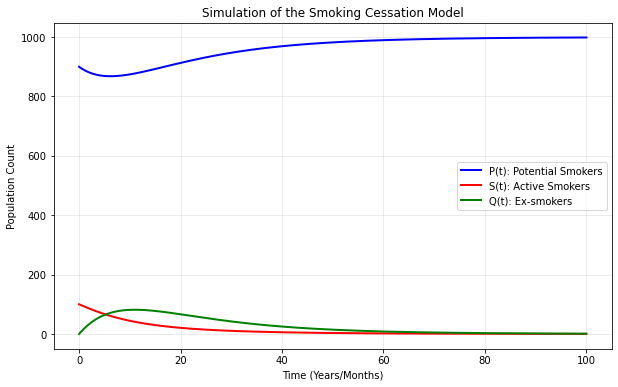

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters
mu = 0.1      # Exit rate from the school system
gamma = 0.2   # Smoking cessation rate
beta = 0.25   # Transmission rate (contact * probability)
N = 1000      # Total population size

# Differential equation system
def smoking_model(y, t, mu, gamma, beta, N):
    P, S, Q = y
    # dP/dt: Change in Potential Smokers
    dPdt = mu*N - (beta*P*S)/N - mu*P
    # dS/dt: Change in Active Smokers
    dSdt = (beta*P*S)/N - (mu+gamma)*S
    # dQ/dt: Change in Permanently Quit Smokers
    dQdt = gamma*S - mu*Q
    return [dPdt, dSdt, dQdt]

# Initial conditions
# 900 potential smokers, 100 active smokers, 0 quitters
y0 = [900, 100, 0]  
t = np.linspace(0, 100, 1000)

# Solve the ODE (Ordinary Differential Equation)
solution = odeint(smoking_model, y0, t, args=(mu, gamma, beta, N))

# Extracting results
P = solution[:, 0]
S = solution[:, 1]
Q = solution[:, 2]

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(t, P, label="P(t): Potential Smokers", color='blue', linewidth=2)
plt.plot(t, S, label="S(t): Active Smokers", color='red', linewidth=2)
plt.plot(t, Q, label="Q(t): Ex-smokers", color='green', linewidth=2)

plt.legend(loc='best')
plt.xlabel("Time (Years/Months)")
plt.ylabel("Population Count")
plt.title("Simulation of the Smoking Cessation Model")
plt.grid(True, alpha=0.3)
plt.show()

#### Interpretation of Time-Series Simulation Results

The numerical simulation of the smoking model, using the parameters $\mu=0.1$, $\gamma=0.2$, and $\beta=0.25$, provides a clear view of the long-term trends within the school population.

#### Threshold Analysis ($R_0$)
The behavior of the curves is fundamentally determined by the \textbf{Basic Reproduction Number}. For this model, it is calculated as:
$$R_0 = \frac{\beta}{\mu + \gamma} = \frac{0.25}{0.1 + 0.2} = \frac{0.25}{0.3} \approx 0.83 $$
Since \textbf{$R_0 < 1$}, the rate at which new smokers are "recruited" is lower than the rate at which individuals stop smoking or leave the school system. Mathematically, this implies that the smoking habit cannot sustain itself.

#### Dynamics of the Population Compartments
As seen in the generated plot, the populations evolve as follows:

##### Potential Smokers ($P$): 
    The blue curve trends toward N=1000. As the "epidemic" of smoking fails to take hold, the entire population eventually returns to the potential smoker category.
##### Active Smokers (S): 
The red curve shows a continuous decline from the initial 100 individuals toward zero. This confirms that smokers are quitting or graduating faster than new ones are starting.
##### Ex-smokers (Q):
    The green curve initially increases as current smokers move into the "quit" category. However, because the source (S) is depleting and individuals leave the system at rate $\mu$, this population also eventually falls to zero.



#### Stability and Equilibrium}
The simulation demonstrates that the system converges to the $\textbf{Disease-Free Equilibrium (DFE)}$ located at (P, S, Q) = (1000, 0, 0). 

    Because R_0 < 1, the DFE is locally asymptotically stable.
     From a public health perspective, these results suggest that the current cessation rate ($\gamma$) and transmission rate ($\beta$) are sufficient to eliminate smoking in this environment over time.